# Faktoryzacja liczb na czynniki pierwsze

In [1]:
import itertools
import math
import random
import time
from collections import Counter
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

## Wstęp

Tematem dzisiejszego laboratorium są algorytmy faktoryzacji liczb naturalnych na czynniki pierwsze.

Każda liczba naturalna $n$ posiada unikalną faktoryzację postaci $n = p_1^{\alpha_1} p_2^{\alpha_2} \cdots p_k^{\alpha_k}$.
W kodzie reprezentować będziemy ją w postaci obiektu typu `Counter` - lekko rozszerzonego słownika, w którym kluczami będą liczby pierwsze,
zaś wartościami - odpowiadające im potęgi.

By zweryfikować, że faktoryzacja $\{(p_1, \alpha_1), \ldots, (p_k, \alpha_k)\}$ jest poprawna, musimy sprawdzić dwa warunki:

- $p_1^{\alpha_1} p_2^{\alpha_2} \cdots p_k^{\alpha_k} = n$
- $p_1,\ldots,p_k$ są liczbami pierwszymi

Do sprawdzenia drugiego warunku możemy wykorzystać test Millera-Rabina zaimplementowany na poprzednim laboratorium.

In [2]:
def miller_rabin_test(n: int, allow_probable: bool = False) -> bool:
    """Deterministic Miller-Rabin algorithm for primes ~< 3.32e24.

    Uses numerical analysis results to return whether or not the passed number
    is prime. If the passed number is above the upper limit, and
    allow_probable is True, then a return value of True indicates that n is
    probably prime. This test does not allow False negatives- a return value
    of False is ALWAYS composite.

    Parameters
    ----------
    n : int
        The integer to be tested. Since we usually care if a number is prime,
        n < 2 returns False instead of raising a ValueError.
    allow_probable: bool, default False
        Whether or not to test n above the upper bound of the deterministic test.

    Raises
    ------
    ValueError

    Reference
    ---------
    https://en.wikipedia.org/wiki/Miller%E2%80%93Rabin_primality_test
    """
    if n == 2:
        return True
    if not n % 2 or n < 2:
        return False
    if n > 5 and n % 10 not in (1, 3, 7, 9):  # can quickly check last digit
        return False
    if n > 3_317_044_064_679_887_385_961_981 and not allow_probable:
        raise ValueError(
            "Warning: upper bound of deterministic test is exceeded. "
            "Pass allow_probable=True to allow probabilistic test. "
            "A return value of True indicates a probable prime."
        )
    # array bounds provided by analysis
    bounds = [
        2_047,
        1_373_653,
        25_326_001,
        3_215_031_751,
        2_152_302_898_747,
        3_474_749_660_383,
        341_550_071_728_321,
        1,
        3_825_123_056_546_413_051,
        1,
        1,
        318_665_857_834_031_151_167_461,
        3_317_044_064_679_887_385_961_981,
    ]

    primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41]
    plist = []
    for idx, _p in enumerate(bounds, 1):
        if n < _p:
            # then we have our last prime to check
            plist = primes[:idx]
            break
    d, s = n - 1, 0
    # break up n -1 into a power of 2 (s) and
    # remaining odd component
    # essentially, solve for d * 2 ** s == n - 1
    while d % 2 == 0:
        d //= 2
        s += 1
    for prime in plist:
        pr = False
        for r in range(s):
            m = pow(prime, d * 2**r, n)
            # see article for analysis explanation for m
            if (r == 0 and m == 1) or ((m + 1) % n == 0):
                pr = True
                # this loop will not determine compositeness
                break
        if pr:
            continue
        # if pr is False, then the above loop never evaluated to true,
        # and the n MUST be composite
        return False
    return True

In [3]:
def isprime(n):
    return miller_rabin_test(n, allow_probable=True)

In [4]:
def reconstruct(factors):
    n = 1
    for p, k in factors.items():
        n *= p**k

    return n

In [5]:
def check_factorization(n, factors):
    return reconstruct(factors) == n and all(isprime(p) for p in factors)

Niektóre algorytmy faktoryzacji wymagają listy wszystkich liczb pierwszych mniejszych od zadanego górnego ograniczenia.
Możemy wydajnie stworzyć taką listę przy pomocy sita Eratostenesa.

In [6]:
def sieve(n):
    array = np.ones(n + 1, dtype=bool)
    array[:2] = False

    for i in range(2, math.isqrt(n) + 1):
        if array[i]:
            array[2 * i::i] = False

    return array

In [7]:
MAX_N = 100_000_000

IS_PRIME = sieve(MAX_N)
PRIMES = np.flatnonzero(IS_PRIME).tolist()

Może przydać nam się również małe pomocnicze narzędzie do mierzenia czasu.

In [8]:
class stopwatch:
    def __init__(self, silent=False):
        self.silent = silent

    def __enter__(self):
        self.start = time.monotonic()
        return self

    def __exit__(self, exc_type, exc_value, exc_traceback):
        self.end = time.monotonic()
        self.elapsed = self.end - self.start

        if not self.silent:
            print(f"elapsed: {s.elapsed:.3f} s")

In [9]:
with stopwatch() as s:
    sieve(10_000_000)

elapsed: 0.011 s


### Zadanie 0

Uzupełnij implementację funkcji `isprime` przenosząc stosowne fragmenty kodu ze swojego rozwiązania poprzedniego laboratorium.

## Metoda próbnego dzielenia (trial division)

Najprostsza metoda faktoryzacji to metoda próbnego dzielenia - sprawdzamy po kolei, czy liczby $k = 2,\ldots,\lfloor \sqrt{n} \rfloor$ są dzielnikami $n$.

In [10]:
def factorize_trial_division(n):
    factors = Counter()

    i = 2
    while i * i <= n:
        while n % i == 0:
            factors[i] += 1
            n //= i

        i += 1

    # Na końcu zostajemy z największym czynnikiem,
    # chyba że występuje w potędzie > 1
    if n != 1:
        factors[n] += 1

    return factors

Możemy przetestować ją na liczbach $\leq 10^6$.

In [11]:
def measure_time(n_max, factorize):
    elapsed = 0

    for n in range(1, n_max + 1):
        with stopwatch(silent=True) as s:
            factors = factorize(n)
        
        if not check_factorization(n, factors):
            print(f"Invalid factorization for n = {n}: {factors}")

        elapsed += s.elapsed

    return elapsed

In [12]:
elapsed = measure_time(1_000_000, factorize_trial_division)
print(f"Trial division: {elapsed:.2f} s")

Trial division: 8.87 s


### Analiza wydajności - przykład

W celu przeprowadzenia bardziej wnikliwej analizy wydajności, musimy sięgnąć po większe liczby.
Dla metody trial division rozsądnym zakresem będą liczby o rozmiarze np. 10-50 bitów.
Losową liczbę o zadanej ilości bitów możemy wygenerować przy pomocy funkcji `getrandbits` z modułu `random`.

In [13]:
def rand_int(bits):
    n = random.getrandbits(bits)
    n |= 1 << (bits - 1)
    return n

<div class="alert alert-block alert-info">
    Poniższe fragmenty kodu stanowią opcjonalny szablon,
    na podstawie którego będzie można dokonać realizacji niektórych kolejnych zadań.
</div>

Najpierw potrzebujemy danych - zbieramy wyniki z fraktoryzacji 1000 losowych liczb.

In [14]:
results = []

for i in tqdm(range(1000)):
    bits = random.randint(10, 50)
    n = rand_int(bits)

    with stopwatch(silent=True) as s:
        factors = factorize_trial_division(n)

    if not check_factorization(n, factors):
        print(f"Failure for {n}: {factors}")

    result = dict(time=s.elapsed, n=n, factors=factors)
    results.append(result)

100%|██████████| 1000/1000 [00:14<00:00, 68.82it/s]


Rozkład długości (w bitach) wylosowanych liczb powinien być mniej więcej jednorodny.

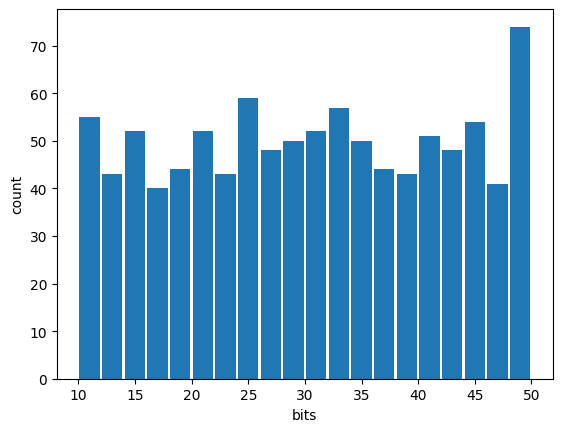

In [15]:
key = lambda r: r["n"].bit_length()

values = [key(r) for r in results]
counts, bins = np.histogram(values, bins=20)
plt.hist(bins[:-1], bins, weights=counts, rwidth=0.9)
plt.xlabel("bits")
plt.ylabel("count")
plt.show()

Następnie grupujemy dane zależnie od rozmiaru faktoryzowanej liczby ...

In [16]:
def group_by(data, key, bins):
    inds = np.digitize([key(r) for r in data], bins)
    data_bins = [[] for _ in bins]

    for i, idx in enumerate(inds):
        data_bins[idx - 1].append(data[i])

    return data_bins

In [17]:
data_bins = group_by(results, key, bins)

... usuwamy puste kubełki ...

In [18]:
nonempty = [data for data in data_bins if data]
mask = np.array([len(data) > 0 for data in data_bins])
bins = bins[mask]

... i liczymy statystyki.

In [19]:
def over_time(f):
    return np.array([f([r["time"] for r in data]) for data in nonempty])

In [20]:
times = over_time(np.mean)
times_min = over_time(np.min)
times_max = over_time(np.max)
times_std = over_time(np.std)

Intuicyjnie możemy oczekiwać, że czas faktoryzacji metodą trial division będzie proporcjonalny do $\sqrt{n}$.
Analizując złożoność algorytmów faktoryzacji operujemy raczej na rozmiarze liczby w bitach niż na jej wartości.
W tym kontekście zależność ta przekłada się na $T \sim 2^{B / 2}$, gdzie $T$ to czas, a $B$ to ilość bitów,
$B = \lceil \log_2 n\rceil$.

Innymi słowy, oczekujemy, że
$$
\log_2 T \approx \frac{1}{2} B + \beta
$$
Możemy zbadać tę hipotezę przy użyciu regresji liniowej zastosowanej do zebranych danych.

In [21]:
# Dla małych liczb czasy mogą być niezbyt miarodajne
skip = 10

B = bins[skip:]
T = times[skip:]

a, b = np.polyfit(B, np.log2(T), deg=1)

estimate = 2 ** (a * bins + b)

Jeśli wszystko poszło dobrze, $a$ powinno być bliskie $1/2$.

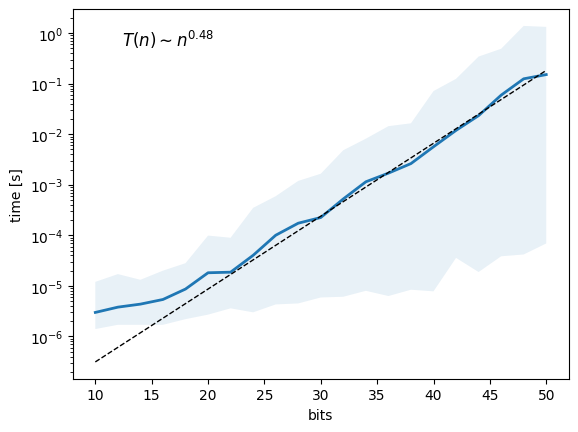

In [22]:
fig, ax = plt.subplots()
ax.semilogy(bins, times, linewidth=2)
ax.semilogy(bins, estimate, linestyle="--", color="black", linewidth=1)
ax.fill_between(bins, times_min, times_max, alpha=0.1)
# ax.fill_between(bins, times - times_std, times + times_std, alpha=0.1)
ax.set_xlabel("bits")
ax.set_ylabel("time [s]")
ax.text(0.1, 0.9, rf"$T(n) \sim n^{{{a:.2f}}}$", transform=ax.transAxes, fontsize=12)
plt.show()

### Zadanie 1

1. Jak wygląda zależność czasu faktoryzacji metodą trial division od rozmiaru największego czynnika pierwszego? Przedstaw ją na wykresie podobnym do powyższego. Która wielkość pozwala dokładniej przewidzieć czas faktoryzacji: rozmiar liczby, czy rozmiar jej największego czynnika pierwszego?
2. Wariant metody trial division jest często używany jako pierwszy krok bardziej złożonych metod. Zamiast próbować dzielić przez wszystkie liczby aż do $\lfloor \sqrt{n}\rfloor$, próbujemy wszystkich liczb pierwszych mniejszych, niż pewne zadane górne ograniczenie. Zaimplementuj funkcję realizującą taką częściową faktoryzację. Powinna ona przyjmować liczbę $n$ oraz górne ograniczenie na sprawdzane liczby pierwsze, a zwracać znalezioną częściową faktoryzację oraz niesfaktoryzowaną "resztę" która pozostała z $n$.

In [23]:
def factor_out_small_primes(n, upto=1000):
    """
    >>> factor_out_small_primes(20020, upto=7)
    (Counter({2: 2, 5: 1, 7: 1}), 143)
    """
    factors = Counter()
    for p in PRIMES:
        if p > upto or p * p > n:
            break
        while n % p == 0:
            factors[p] += 1
            n //= p
    return factors, n

### Rozwiązanie

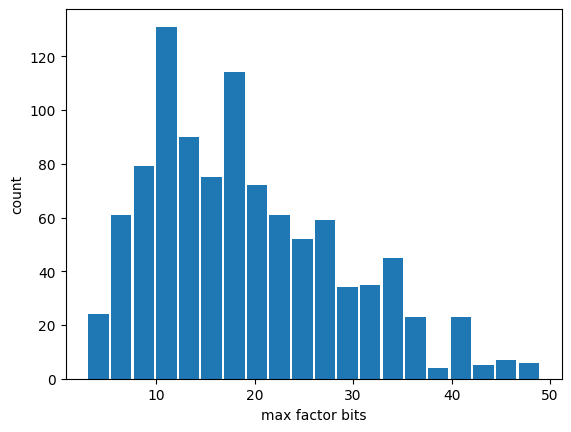

In [24]:
key = lambda r: max(r["factors"]).bit_length()

values = [key(r) for r in results]
counts, bins = np.histogram(values, bins=20)
plt.hist(bins[:-1], bins, weights=counts, rwidth=0.9)
plt.xlabel("max factor bits")
plt.ylabel("count")
plt.show()

In [25]:
data_bins = group_by(results, key, bins)

nonempty = [data for data in data_bins if data]
mask = np.array([len(data) > 0 for data in data_bins])
bins = bins[mask]

times = over_time(np.mean)
times_min = over_time(np.min)
times_max = over_time(np.max)
times_std = over_time(np.std)

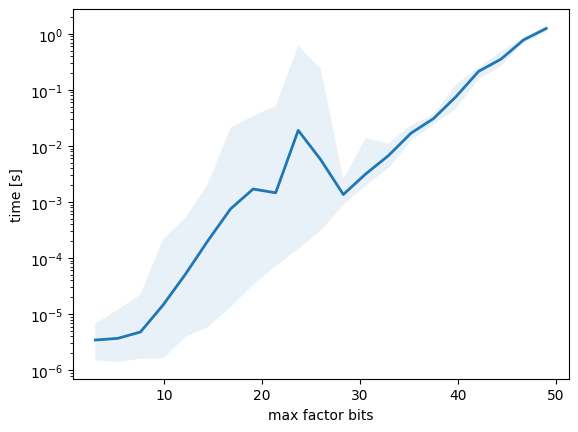

In [26]:
fig, ax = plt.subplots()
ax.semilogy(bins, times, linewidth=2)
ax.fill_between(bins, times_min, times_max, alpha=0.1)
ax.set_xlabel("max factor bits")
ax.set_ylabel("time [s]")
plt.show()

## Sito kołowe (wheel factorization)

Sito kołowe to optymalizacja metody dzielenia próbnego poprzez pomijanie niektórych liczb. Przykładowo, jeśli sprawdziliśmy, czy nasza liczba jest podzielna przez $2$, możemy pominąć w dalszych testach wszystkie liczby parzyste. Możemy zatem w pętli zwiększać licznik o $2$ zamiast o $1$, zmniejszając ilość testów o połowę. Sito kołowe to uogólnienie tego pomysłu polegające na pomijaniu wielokrotności pierwszych $k$ liczb pierwszych.

Działanie sita kołowego najłatwiej pokazać na niewielkim, konkretnym przykładzie. Załóżmy, że chcemy pomijać w testach wszystkie wielokrotności liczb $2$, $3$ i $5$. O tym, czy liczba jest podzielna przez którąś z nich, decyduje reszta z dzielenia przez $2 \times 3 \times 5 = 30$. Niepodzielne przez $2$, $3$ i $5$ są dokładnie te liczby, których reszta z dzielenia przez $30$ nie jest podzielna przez żadną z tych liczb, tzn. jest zawarta w
$$
1, 7, 11, 13, 17, 19, 23, 29
$$
By wydajnie generować takie liczby, zaczniemy od $7$ i będziemy poruszać się do przodu o kolejne odstępy pomiędzy tymi resztami:
$$
\underbrace{4}_{11 - 7}, \underbrace{2}_{13 - 11}, \underbrace{4}_{17 - 13}, \underbrace{2}_{19 - 17},
\underbrace{4}_{23 - 19}, \underbrace{6}_{29 - 23}, \underbrace{2}_{1 - 29 \bmod{30}}, \underbrace{6}_{7 - 1}, \ldots
$$
Gdy dochodzimy do końca tablicy odstępów, zapętlamy się. Generacja ciągu wygląda następująco:
$$
7 \xrightarrow{+4}
11 \xrightarrow{+2}
13 \xrightarrow{+4}
17 \xrightarrow{+2}
19 \xrightarrow{+4}
23 \xrightarrow{+6}
29 \xrightarrow{+2}
31 \xrightarrow{+6}
37 \xrightarrow{+4}
41 \xrightarrow{+2}
43 \xrightarrow{+4}
47 \xrightarrow{+2}
49 \xrightarrow{+4}
53 \xrightarrow{+6}
59 \xrightarrow{+2}
61 \xrightarrow{+6}
67 \xrightarrow{+4}
71 \xrightarrow{+2}
73 \xrightarrow{+4} \ldots
$$

By sfaktoryzować liczbę $n$ metodą sita kołowego:
- generujemy tablicę odstępów dla liczb pierwszych $p_1,\ldots,p_k$ (można to zrobić raz i reużywać ją do wielu faktoryzacji)
- sprawdzamy, czy $n$ jest podzielna przez $p_1,\ldots,p_k$
- przy pomocy tablicy odstępów generujemy ciąg potencjalnych dzielników i wykonujemy dzielenie próbne

### Zadanie 2

1. Zaimplementuj sito kołowe i przetestuj poprawność jego działania.
2. Jaki zysk w praktyce daje sito kołowe w zależności od ilości użytych liczb pierwszych? Przetestuj zyski na liczbach $\leq 10^6$ (można użyć funkcji `measure_time`). Narysuj wykres przyspieszenia w stosunku do bazowej metody trial division (na osi $X$ ilość użytych do sita liczb pierwszych, na osi $Y$ czas zwykłego trial division podzielony przez czas wersji z sitem).
3. Jak rosną czas i pamięć potrzebne do zbudowania sita kołowego wraz z ilością użytych liczb pierwszych?
4. (**dodatkowe**) "Idealne" (nieskończone) sito kołowe sprawdzałoby wyłącznie podzielność przez liczby pierwsze. Jakie przyspieszenie pozwoliłoby to osiągnąć dla liczb $\leq 10^6$? (lista `PRIMES` zawiera wszystkie liczby pierwsze potrzebne do testu). Jak zmieniałoby się to przyspieszenie wraz z rozmiarem faktoryzowanych liczb? (**[HINT](https://en.wikipedia.org/wiki/Prime_number_theorem)**)

### Rozwiązanie

In [27]:
@lru_cache(maxsize=None)
def build_wheel(k):
    """
    >>> build_wheel(3)
    ([2, 3, 5], 7, (4, 2, 4, 2, 4, 6, 2, 6))
    """
    wheel_primes = PRIMES[:k]
    circumference = math.prod(wheel_primes)

    coprimes = [
        x for x in range(2, circumference + 2) if math.gcd(x, circumference) == 1
    ]
    full_cycle = itertools.chain(coprimes, [coprimes[0] + circumference])

    gaps = tuple(b - a for a, b in itertools.pairwise(full_cycle))

    return wheel_primes, coprimes[0], gaps


def factorize_wheel(n, k=4):
    """
    >>> factorize_wheel(20020, k=4)
    Counter({2: 2, 5: 1, 7: 1, 11: 1, 13: 1})
    """
    factors = Counter()
    wheel_primes, p, gaps = build_wheel(k)

    for prime in wheel_primes:
        while n % prime == 0:
            factors[prime] += 1
            n //= prime

    for gap in itertools.cycle(gaps):
        if p * p > n:
            break
        while n % p == 0:
            factors[p] += 1
            n //= p
        p += gap

    if n > 1:
        factors[n] += 1

    return factors

In [28]:
n_limit = 1000
k_limit = 8

for n in range(1, n_limit + 1):
    for k in range(1, k_limit + 1):
        assert check_factorization(n, factorize_wheel(n, k)), f"Wrong factorization for {n=} and {k=}"
print(f"Factorization correct up to n={n_limit} and k={k_limit}")

Factorization correct up to n=1000 and k=8


In [29]:
n_max = 1_000_000
k_values = [k for k in range(1, k_limit + 1)]
speedups = []

td_time = measure_time(n_max, factorize_trial_division)

for k in k_values:
    w_time = measure_time(n_max, lambda n: factorize_wheel(n, k))
    speedup = td_time / w_time
    speedups.append(speedup)
    print(f"{speedup:.2f}x speedup for {k=:d} ({td_time=:.2f}s vs {w_time=:.2f}s)")

1.55x speedup for k=1 (td_time=9.02s vs w_time=5.84s)
2.04x speedup for k=2 (td_time=9.02s vs w_time=4.43s)
2.20x speedup for k=3 (td_time=9.02s vs w_time=4.09s)
2.45x speedup for k=4 (td_time=9.02s vs w_time=3.68s)
2.51x speedup for k=5 (td_time=9.02s vs w_time=3.59s)
2.49x speedup for k=6 (td_time=9.02s vs w_time=3.63s)
2.84x speedup for k=7 (td_time=9.02s vs w_time=3.18s)
2.76x speedup for k=8 (td_time=9.02s vs w_time=3.27s)


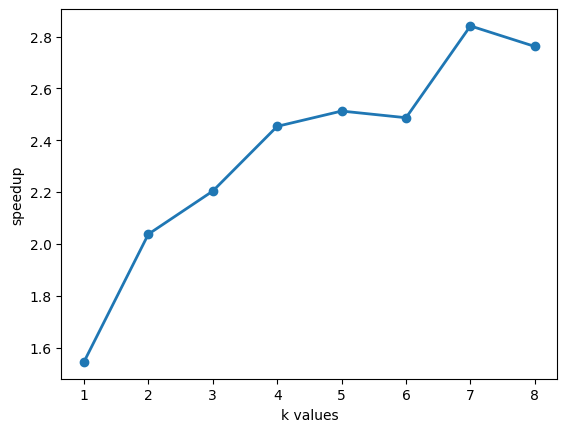

In [30]:
fig, ax = plt.subplots()
ax.plot(k_values, speedups, marker="o", linewidth=2)
ax.set_xlabel("k values")
ax.set_ylabel("speedup")
plt.show()

## Metoda $\rho$ Pollarda

Niech $n$ będzie liczbą, którą chcemy sfaktoryzować, zaś $p$ jej czynnikiem pierwszym.
Jeśli $x, y \in \mathbb{Z} / n\mathbb{Z}$ spełniają $x \equiv y \pmod p$, to największy wspólny dzielnik $d = (x - y, n)$ jest dzielnikiem $n$ podzielnym przez $p$.
Jeśli $d \neq n$, to $d$ jest nietrywialnym dzielnikiem $n$.
Jeśli potrafimy zatem znaleźć takie $x$ i $y$, to jest duża szansa, że uda się w ten sposób rozłożyć $n$.
Wybierając losowe liczby z $\{1,\ldots,n\}$ mamy sporą szansę na znalezienie ich wśród pierwszych $\sim \sqrt{p}$ liczb,
ale sprawdzeneie wszystkich par kosztowałoby $\mathcal{O}(p)$ - tak samo jak metoda próbnego dzielenia.
Musimy więc zrobić to sprytniej.

W metodzie $\rho$ Pollarda wybieramy pewną funkcję wielomianową $f$, zazwyczaj postaci $f(x) = x^2 + b$.
Możemy ją interpretować jako funkcję $f\colon \mathbb{Z}/n\mathbb{Z} \to \mathbb{Z}/n\mathbb{Z}$ biorąc jej wartości modulo $n$.
Przy jej pomocy generujemy ciąg elementów $x_1,x_2,\ldots$ tak, że $x_{k+1} = f(x_k)$.
Ciąg $\{x_k\}$ modulo $n$ indukuje ciąg $\bar{x}_k = x_k \bmod p$.
Dzięki temu, że $f$ jest wielomianem, mamy również $\bar{x}_{k+1} = f(\bar{x}_k) \bmod p$.
Dzięki temu, że $\bar{x}_k$ jest generowany poprzez iteracje funkcji,
po pewnej liczbie iteracji musi wpaść w cykl, tzn. istnieje $k \geq 1$ takie, że $\bar{x}_{i + mk} = \bar{x}_i$ dla odpowiednio dużego $i$ i dowolnego $m \geq 0$.
Wówczas $x_{i+mk} \equiv x_i \pmod p$ i jeśli $x_{i+mk} \not\equiv x_i \pmod n$, to $(x_{i+mk} - x_i, n)$ będzie nietrywialnym dzielnikiem $n$.
By znaleźć taki cykl, możemy użyć znanego z WDI / ASD algorytmu żółwia i zająca
(dwa wskaźniki, jeden skacze o $1$ węzeł, drugi o $2$, jeśli istnieje cykl to w końcu się spotkają).

#### Algorytm

1. Wylosuj $1 \leq b \leq n - 3$, wówczas $f(x) = x^2 + b$.
2. Wylosuj $0 \leq x < n$.
3. $y \gets x$
4. Dopóki nie przerwiemy:
   - $x \gets f(x)$
   - $y \gets f(f(y))$
   - $d \gets (x - y, n)$
   - jeśli $d = n$, przerwij algorytm i zasygnalizuj porażkę
   - jesli $d \neq 1$, zwróć $d$ jako nietrywialny dzielnik $n$

Możemy zrobić kilka iteracji dla różnych wartości $x$ i $b$ by zwiększyć szansę na odnalezienie czynnika.
Jeśli wykonujemy tylko jedną iterację, możemy użyć standardowych wartości $x = 2$, $b = 1$.

Należy pamiętać, że metoda $\rho$ Pollarda znajdzie **dzielnik** faktoryzowanej liczby - niekoniecznie będzie to liczba pierwsza. Szukając rozkładu na czynniki pierwsze musimy sprawdzić, czy otrzymane dzielniki są liczbami pierwszymi, i w razie potrzeby je sfaktoryzować.

**Uwaga** Nie ma gwarancji, że metoda $\rho$ Pollarda będzie w stanie znaleźć czynnik. Dla niektórych liczb algorytm nie działa (np. dla $4$). Po pewnej liczbie iteracji nie pozostaje nam nic innego, jak się poddać i przekazać pałeczkę innemu algorytmowi faktoryzacji, np. trial division.

#### Sugestie wydajnościowe
- Najlepiej zacząć od sprawdzenia podzielności przez małe liczby pierwsze. Można w tym celu wykorzystać metodę `factor_out_small_primes` z Zadania 1.
- Przed faktoryzacją opłaca się sprawdzić, czy przypadkiem liczba nie jest pierwsza, używając wydajnego testu probabilistycznego.

### Zadanie 3

1. Zaimplementuj metodę $\rho$ Pollarda.
2. Jak zależy jej wydajność od następujących wielkości? Która z nich ma największy wpływ na czas działania? Przeprowadź testy na losowych liczbach o rozmiarze 40-100 bitów i przedstaw wyniki na odpowiednich wykresach.
   - rozmiar faktoryzowanej liczby
   - rozmiar największego czynnika pierwszego
   - rozmiar drugiego największego czynnika pierwszego
3. Jak wygląda wydajność metody $\rho$ Pollarda w porównaniu z metodą próbnego dzielenia? Przedstaw zależność czasu faktoryzacji od rozmiaru liczby na jednym wykresie.
4. (**dodatkowe**) Przy użyciu wydajnej metody faktoryzacji możemy dowiedzieć się czegoś na temat właściwości statystycznych dużych liczb. Jak wyglądają rozkłady następujących wielkości dla liczb np. 80-bitowych? Narysuj odpowiednie histogramy.
   - rozmiar największego czynnika pierwszego
   - rozmiar drugiego największego czynnika pierwszego
   - rozmiar najmniejszego czynnika pierwszego
   - ilość unikalnych czynników pierwszych
   - najwyższa potęga występująca w rozkładzie
5. (**dodatkowe**) Istnieje alternatywny, bardziej wydajny sposób znajdowania cykli: **[algorytm Brenta](https://en.wikipedia.org/wiki/Cycle_detection#Brent.27s_algorithm)**. Zmodyfikuj implementację faktoryzacji $\rho$ Pollarda tak, by znajdował cykle z wykorzystaniem tej metody. Porównaj wydajność obu rozwiązań.

### Rozwiązanie

In [31]:
def pollard_rho_core(n, x=2, b=1):
    """Finds a non-trivial factor of n using Pollard's rho."""
    if n % 2 == 0:
        return 2

    f = lambda x: (x * x + b) % n
    y = x

    while True:
        x = f(x)
        y = f(f(y))
        d = math.gcd(x - y, n)

        if d == n:
            return None
        if d != 1:
            return d

In [32]:
def factorize_pollard_rho(n, max_retries=1000, small_primes_upto=1000):
    """
    >>> factorize_pollard_rho(20020, max_retries=1000, small_primes_upto=1000)
    Counter({2: 2, 5: 1, 7: 1, 11: 1, 13: 1})
    """
    factors, n = factor_out_small_primes(n, upto=small_primes_upto)

    stack = [n]
    while stack:
        n = stack.pop()

        if n == 1:
            continue

        if isprime(n):
            factors[n] += 1
            continue

        for _ in range(max_retries):
            x = random.randint(0, n - 1)
            b = random.randint(1, max(1, n - 3))

            d = pollard_rho_core(n, x, b)

            if d is not None:
                stack.extend([d, n // d])
                break
        else:
            return None  # failed to find a factor in max_retries

    return factors

In [33]:
n_limit = 100_000

for n in range(1, n_limit + 1):
    factors = factorize_pollard_rho(n, max_retries=1000, small_primes_upto=1)
    assert check_factorization(n, factors), f"Wrong factorization for {n=}"
print(f"Factorization correct up to n={n_limit}")

Factorization correct up to n=100000


In [34]:
def factorize_pollard_rho_stackless(n, max_retries=1000, small_primes_upto=1000):
    """
    >>> factorize_pollard_rho_stackless(20020, max_retries=1000, small_primes_upto=1000)
    Counter({2: 2, 5: 1, 7: 1, 11: 1, 13: 1})
    """
    factors, n = factor_out_small_primes(n, upto=small_primes_upto)

    d = n
    while n > 1:
        if isprime(d):
            while n % d == 0:
                factors[d] += 1
                n //= d
            d = n
            continue

        for _ in range(max_retries):
            x = random.randint(0, d - 1)
            b = random.randint(1, max(1, d - 3))

            found_d = pollard_rho_core(d, x, b)

            if found_d is not None:
                d = found_d
                break
        else:
            return None  # failed to find a factor in max_retries

    return factors

In [35]:
n_limit = 100_000

for n in range(1, n_limit + 1):
    factors = factorize_pollard_rho_stackless(n, max_retries=1000, small_primes_upto=1)
    assert check_factorization(n, factors), f"Wrong factorization for {n=}"
print(f"Factorization correct up to n={n_limit}")

Factorization correct up to n=100000


In [36]:
results = []

for _ in tqdm(range(1000)):
    bits = random.randint(40, 100)
    n = rand_int(bits)

    with stopwatch(silent=True) as s:
        factors = factorize_pollard_rho(n)

    if not check_factorization(n, factors):
        print(f"Failure for {n}: {factors}")

    result = dict(time=s.elapsed, n=n, factors=factors)
    results.append(result)

100%|██████████| 1000/1000 [00:03<00:00, 313.64it/s]


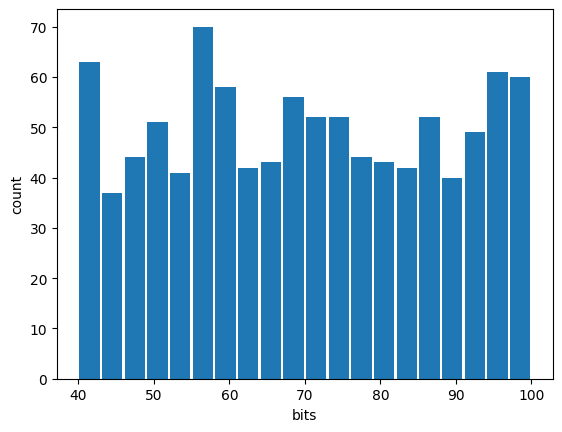

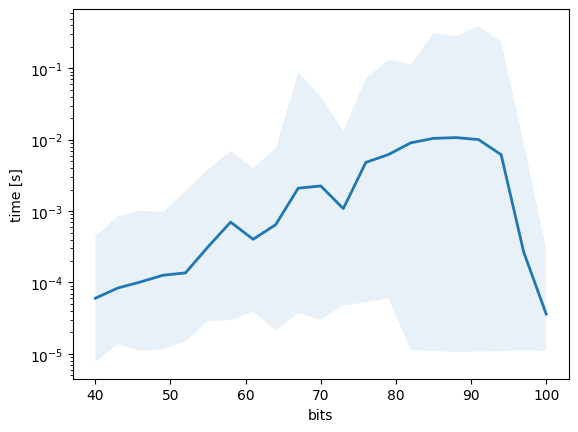

In [37]:
key = lambda r: r["n"].bit_length()

values = [key(r) for r in results]
counts, bins = np.histogram(values, bins=20)
plt.hist(bins[:-1], bins, weights=counts, rwidth=0.9)
plt.xlabel("bits")
plt.ylabel("count")
plt.show()

data_bins = group_by(results, key, bins)

nonempty = [data for data in data_bins if data]
mask = np.array([len(data) > 0 for data in data_bins])
bins = bins[mask]

times = over_time(np.mean)
times_min = over_time(np.min)
times_max = over_time(np.max)
times_std = over_time(np.std)

fig, ax = plt.subplots()
ax.semilogy(bins, times, linewidth=2)
ax.fill_between(bins, times_min, times_max, alpha=0.1)
ax.set_xlabel("bits")
ax.set_ylabel("time [s]")
plt.show()

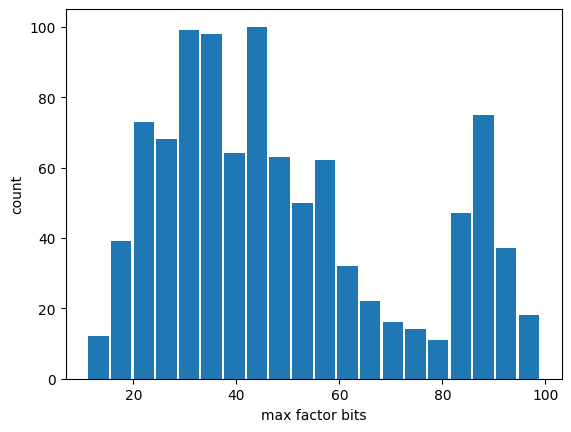

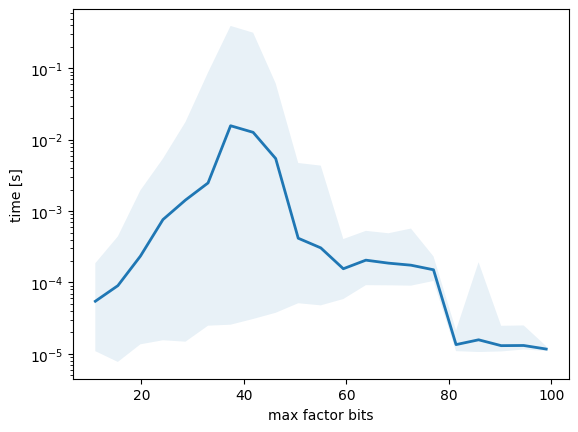

In [38]:
key = lambda r: max(r["factors"]).bit_length()

values = [key(r) for r in results]
counts, bins = np.histogram(values, bins=20)
plt.hist(bins[:-1], bins, weights=counts, rwidth=0.9)
plt.xlabel("max factor bits")
plt.ylabel("count")
plt.show()

data_bins = group_by(results, key, bins)

nonempty = [data for data in data_bins if data]
mask = np.array([len(data) > 0 for data in data_bins])
bins = bins[mask]

times = over_time(np.mean)
times_min = over_time(np.min)
times_max = over_time(np.max)
times_std = over_time(np.std)

fig, ax = plt.subplots()
ax.semilogy(bins, times, linewidth=2)
ax.fill_between(bins, times_min, times_max, alpha=0.1)
ax.set_xlabel("max factor bits")
ax.set_ylabel("time [s]")
plt.show()

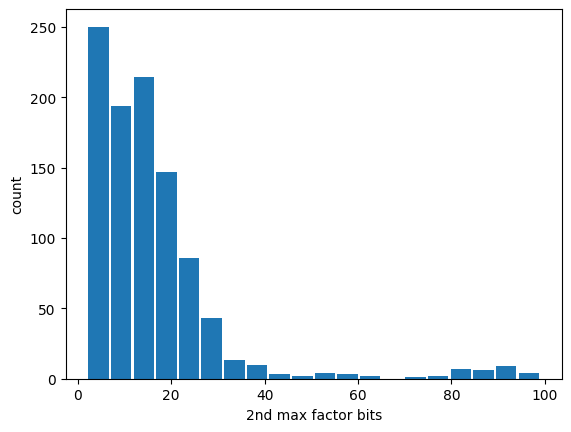

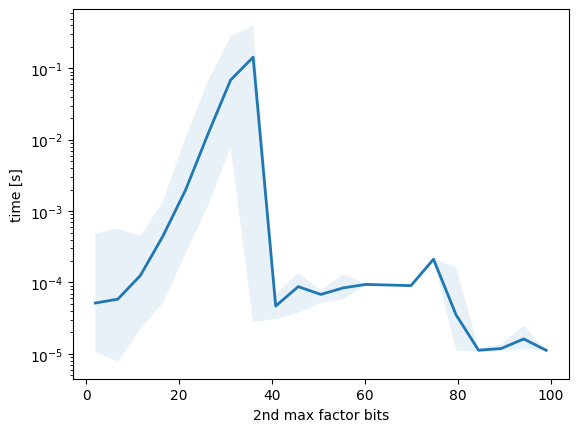

In [39]:
def key(r):
    sorted_factors = sorted(r["factors"])
    if len(sorted_factors) >= 2:
        return sorted_factors[-2].bit_length()
    return sorted_factors[-1].bit_length()

values = [key(r) for r in results]
counts, bins = np.histogram(values, bins=20)
plt.hist(bins[:-1], bins, weights=counts, rwidth=0.9)
plt.xlabel("2nd max factor bits")
plt.ylabel("count")
plt.show()

data_bins = group_by(results, key, bins)

nonempty = [data for data in data_bins if data]
mask = np.array([len(data) > 0 for data in data_bins])
bins = bins[mask]

times = over_time(np.mean)
times_min = over_time(np.min)
times_max = over_time(np.max)
times_std = over_time(np.std)

fig, ax = plt.subplots()
ax.semilogy(bins, times, linewidth=2)
ax.fill_between(bins, times_min, times_max, alpha=0.1)
ax.set_xlabel("2nd max factor bits")
ax.set_ylabel("time [s]")
plt.show()

In [40]:
results = []

for _ in tqdm(range(1000)):
    bits = random.randint(10, 50)
    n = rand_int(bits)

    with stopwatch(silent=True) as s_pr:
        factors_pr = factorize_pollard_rho(n)

    with stopwatch(silent=True) as s_prs:
        factors_prs = factorize_pollard_rho_stackless(n)

    with stopwatch(silent=True) as s_td:
        factors_td = factorize_trial_division(n)

    if not factors_pr == factors_td:
        print(f"Failure for {n}: {factors}")

    result = dict(
        time_pr=s_pr.elapsed,
        time_prs=s_prs.elapsed,
        time_td=s_td.elapsed,
        n=n,
    )
    results.append(result)

100%|██████████| 1000/1000 [00:15<00:00, 65.18it/s]


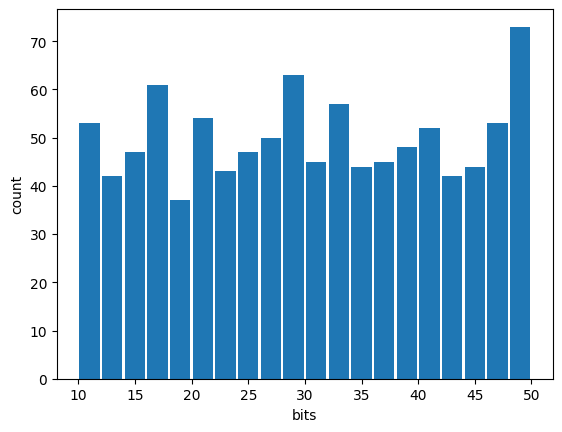

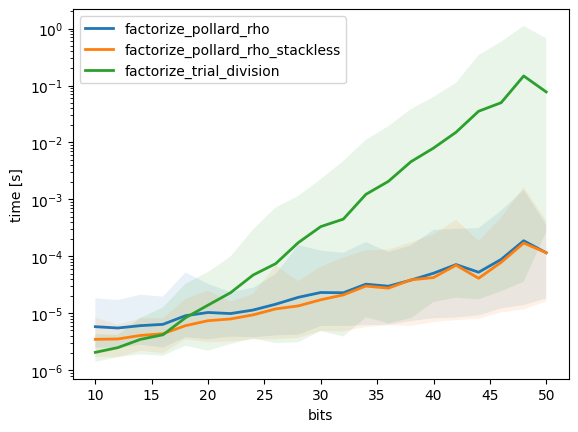

In [41]:
key = lambda r: r["n"].bit_length()

values = [key(r) for r in results]
counts, bins = np.histogram(values, bins=20)
plt.hist(bins[:-1], bins, weights=counts, rwidth=0.9)
plt.xlabel("bits")
plt.ylabel("count")
plt.show()

data_bins = group_by(results, key, bins)

nonempty = [data for data in data_bins if data]
mask = np.array([len(data) > 0 for data in data_bins])
bins = bins[mask]

def over_time_pr(f):
    return np.array([f([r["time_pr"] for r in data]) for data in nonempty])

def over_time_prs(f):
    return np.array([f([r["time_prs"] for r in data]) for data in nonempty])

def over_time_td(f):
    return np.array([f([r["time_td"] for r in data]) for data in nonempty])

times_pr = over_time_pr(np.mean)
times_min_pr = over_time_pr(np.min)
times_max_pr = over_time_pr(np.max)
times_std_pr = over_time_pr(np.std)

times_prs = over_time_prs(np.mean)
times_min_prs = over_time_prs(np.min)
times_max_prs = over_time_prs(np.max)
times_std_prs = over_time_prs(np.std)

times_td = over_time_td(np.mean)
times_min_td = over_time_td(np.min)
times_max_td = over_time_td(np.max)
times_std_td = over_time_td(np.std)

fig, ax = plt.subplots()
ax.semilogy(bins, times_pr, linewidth=2, label="factorize_pollard_rho")
ax.fill_between(bins, times_min_pr, times_max_pr, alpha=0.1)
ax.semilogy(bins, times_prs, linewidth=2, label="factorize_pollard_rho_stackless")
ax.fill_between(bins, times_min_prs, times_max_prs, alpha=0.1)
ax.semilogy(bins, times_td, linewidth=2, label="factorize_trial_division")
ax.fill_between(bins, times_min_td, times_max_td, alpha=0.1)
ax.set_xlabel("bits")
ax.set_ylabel("time [s]")
ax.legend()
plt.show()

## Pollard $p-1$

**Małe Twierdzenie Fermata**. Jeśli $p$ jest liczbą pierwszą i $a$ nie jest podzielne przez $p$, to $a^{p-1} \equiv 1 \pmod p$.

Zasada działania metody $p - 1$ Pollarda jest następująca. Niech $n$ będzie liczbą, którą chcemy sfaktoryzować, a $p$ będzie jednym z jej czynników pierwszych.
Jeśli $M$ jest liczbą podzielną przez $p - 1$, tzn. $M = L(p - 1)$ dla pewnego $L$, to z Małego Twierdzenia Fermata mamy
$$
a^M \equiv a^{L(p-1)} \equiv (a^{p-1})^L \equiv 1^L \equiv 1 \pmod p
$$
tzn. $a^M - 1$ jest podzielne przez $p$.
Skoro $n$ również jest podzielne przez $p$, to ich największy wspólny dzielnik $d = (a^M - 1, n)$ również jest podzielny przez $p$.
Jeśli $d \neq n$, to odnieśliśmy sukces, $d$ jest nietrywialnym dzielnikiem $n$.

Istotą metody $p - 1$ Pollarda jest sposób szukania odpowiedniej liczby $M$.
Wybierzmy dowolną liczbę $B$.
Załóżmy, że $n$ posiada czynnik pierwszy $p$ taki, że rozkład $p - 1 = q_1^{a_1} \ldots q_k^{a_k}$ na czynniki pierwsze spełnia warunek $q_i^{a_i} \leq B$
(mówimy wówczas, że $p - 1$ jest $B$-powersmooth). Niech $M = \operatorname{lcm}\{1,2,\ldots,B\}$.
Przy powyższym założeniu takie $M$ z pewnością jest podzielne przez $p - 1$,
a zatem na mocy wcześniej pokazanego rozumowania, $(a^M - 1, n)$ jest dzielnikiem $n$.
Skoro ostatecznie interesuje nas największy wspólny dzielnik $a^M - 1$ i $n$, wystarczy obliczyć $a^M \bmod n$.

Wartość $M$ możemy obliczyć jako iloczyn wszystkich liczb pierwszych $q \leq B$ podniesionych do największej możliwej potęgi $a$ takiej, że $q^a \leq B$:
$$
M = \prod_{q \leq B,\ q \text{ prime}} q^{\lfloor \log_q B \rfloor}
$$
Możemy myśleć o $M$ jako o największej możliwej liczbie $B$-powersmooth.
Nie musimy obliczać i przechowywać $M$ w całości - by policzyć $a^M \bmod n$ wystarczy zacząć od $a$
i podnosić je do potęg $q^{\lfloor \log_q B \rfloor}$ dla kolejnych liczb pierwszych $q$.
Nie musimy również sprawdzać, czy $(a^M - 1, n)$ jest nietrywialnym dzielnikiem $n$ wyłącznie raz na samym końcu.
Zamiast tego, możemy co pewną liczbę iteracji (np. co 100 liczb pierwszych) sprawdzać, czy częściowy wynik daje nam dzielnik $n$.
Im częściej wykonamy takie sprawdzenie, tym większy będzie koszt obliczeniowy,
ale i tym większa szansa, że "złapiemy" dzielnik zanim $(a^M - 1, n)$ stanie się całym $n$.

#### Algorytm

Wejście: liczba $n$ do sfaktoryzowania, $B$ - parametr

1. wylosuj $2 \leq a \leq n - 1$
2. dla liczb pierwszych $q \leq B$:
   - $f \gets q^{\lfloor \log_q B \rfloor}$
   - $a \gets a^f \pmod n$
   - co ileś iteracji:
     - $d \gets (a - 1, n)$
     - jeśli $d \not\in \{1, n\}$, zwróć $d$ jako nietrywialny dzielnik $n$
     - jeśli $d = n$, przerwij algorytm i zasygnalizuj porażkę

Możemy zrobić kilka iteracji dla różnych wartości $a$ by zwiększyć szansę na odnalezienie czynnika.
Jeśli jednak dla żadnego czynnika pierwszego $p$ liczba $p - 1$ nie jest $B$-powersmooth, algorytm nie ma szans zadziałać.
Można wówczas spróbować zwiększyć wartość parametru $B$, ale dla pewnych liczb nawet to nie zadziała.
Podobnie jak w przypadku metody $\rho$ Pollarda, nie ma gwarancji że metoda $p-1$ Pollarda znajdzie czynnik faktoryzowanej liczby.
Należy dodać jakąś inną metodę jako fallback.

Metoda $p - 1$ Pollarda znajdzie **dzielnik** faktoryzowanej liczby - niekoniecznie będzie to liczba pierwsza. Szukając rozkładu na czynniki pierwsze musimy sprawdzić, czy otrzymane dzielniki są liczbami pierwszymi, i w razie potrzeby je sfaktoryzować.

Odnośnie wydajności - te same sugestie co do metody $\rho$ Pollarda.

### Zadanie 4

1. Zaimplementuj metodę $p - 1$ Pollarda.
2. Jak zależy jej wydajność od następujących wielkości? Przeprowadź wymagane testy i przedstaw wyniki na odpowiednich wykresach.
   - rozmiar faktoryzowanej liczby
   - rozmiar największego czynnika pierwszego
   - rozmiar drugiego największego czynnika pierwszego
   - wartość parametru $B$
3. Jak wypada jej wydajność w porównaniu z metodą $\rho$ Pollarda dla losowych liczb?
4. Porównaj wydajność metod $p-1$ i $\rho$ Pollarda dla liczby $393153263702980669137355399246611499921$. Co jest przyczyną otrzymanego wyniku?
5. (**dodatkowe**) Jak wartość parametru $B$ wpływa na ilość sukcesów (tj. liczb, dla których metoda $p-1$ odnalazła czynnik)? Przedstaw zależność na wykresie.
6. (**dodatkowe**) Spróbuj sfaktoryzować obiema metodami liczbę Fermata $F_{12} = 2^{2^{12}} + 1$. Czy któraś metoda jest w stanie znaleźć jakieś czynniki pierwsze? Nie uda się sfaktoryzować $F_{12}$ w całości, więc może być konieczna modyfikacja kodu tak, by zwracał/wypisywał czynniki na bieżąco.
7. (**dodatkowe$^2$**) Metoda $p - 1$ Pollarda jest przykładem algorytmu z rodziny metod **[opartych o grupy algebraiczne](https://en.wikipedia.org/wiki/Algebraic-group_factorisation_algorithm)**. Inną metodą tego typu jest faktoryzacja przy użyciu krzywych eliptycznych. Poszukaj informacji na jej temat, zaimplementuj ją i porównaj wydajność z innymi metodami z ćwiczeń.

### Rozwiązanie

In [86]:
def pollard_p_minus_1_core(n, B=1000, a=2, check_interval=100):
    """Finds a non-trivial factor of n using Pollard's p-1 method."""
    if n % 2 == 0:
        return 2

    for i, q in enumerate(PRIMES):
        if q > B:
            break

        q_pow = q
        while q_pow * q <= B:
            q_pow *= q

        a = pow(a, q_pow, n)

        if i % check_interval == 0:
            d = math.gcd(a - 1, n)
            if 1 < d < n:
                return d
            if d == n:
                return None

    d = math.gcd(a - 1, n)
    if 1 < d < n:
        return d

    return None

In [87]:
def factorize_pollard_p_minus_1(n, B=1000, max_retries=1000, small_primes_upto=1000):
    """
    >>> factorize_pollard_p_minus_1(20020, B=1000, max_retries=1000, small_primes_upto=1000)
    Counter({2: 2, 5: 1, 7: 1, 11: 1, 13: 1})
    """
    factors, n = factor_out_small_primes(n, upto=small_primes_upto)

    stack = [n]
    while stack:
        n_curr = stack.pop()

        if n_curr == 1:
            continue

        if isprime(n_curr):
            factors[n_curr] += 1
            continue

        for _ in range(max_retries):
            a = random.randint(2, n_curr - 2) if n_curr > 3 else 2
            d = pollard_p_minus_1_core(n_curr, B, a)

            if d is not None:
                stack.extend([d, n_curr // d])
                break
        else:
            return None

    return factors

In [88]:
n_limit = 100_000

for n in range(1, n_limit + 1):
    factors = factorize_pollard_p_minus_1(
        n, B=1000, max_retries=1000, small_primes_upto=1
    )
    assert check_factorization(n, factors), f"Wrong factorization for {n=}"
print(f"Factorization correct up to n={n_limit}")

Factorization correct up to n=100000


In [89]:
results = []
failures_p1 = 0

for _ in tqdm(range(1000)):
    bits = random.randint(30, 70)
    n = rand_int(bits)

    with stopwatch(silent=True) as s_p1:
        factors_p1 = factorize_pollard_p_minus_1(n)

    with stopwatch(silent=True) as s_rho:
        factors_rho = factorize_pollard_rho(n)

    if factors_p1 is None:
        failures_p1 += 1
    elif factors_p1 != factors_rho:
        print(f"Mismatch for {n}!\n p-1 gave: {factors_p1}\n rho gave: {factors_rho}")
        failures_p1 += 1

    result = dict(
        time_p1=s_p1.elapsed, 
        time_rho=s_rho.elapsed, 
        n=n, 
        factors_p1=factors_p1,
        factors_rho=factors_rho
    )
    results.append(result)

print(f"The p-1 method failed for {failures_p1}/1000 random numbers.")

100%|██████████| 1000/1000 [00:27<00:00, 36.72it/s]

The p-1 method failed for 156/1000 random numbers.


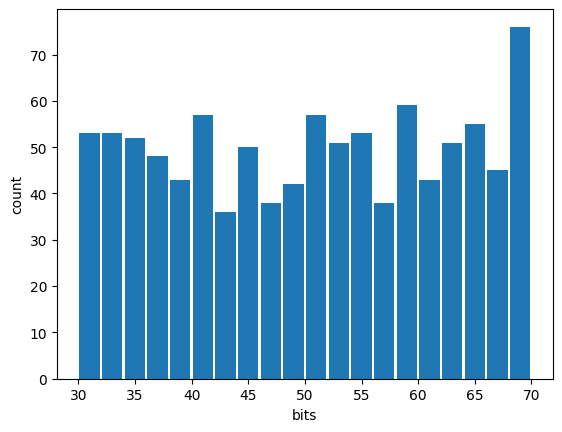

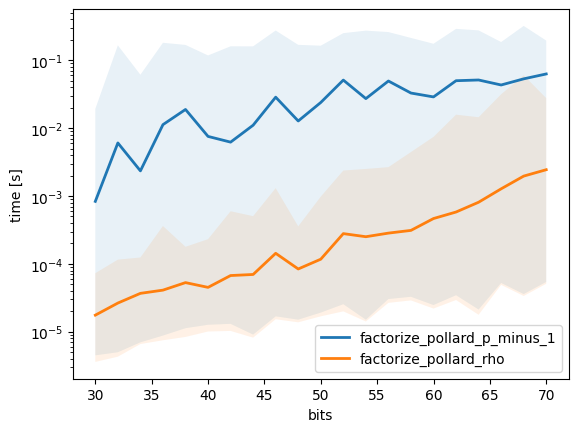

In [90]:
key = lambda r: r["n"].bit_length()

values = [key(r) for r in results]
counts, bins = np.histogram(values, bins=20)
plt.hist(bins[:-1], bins, weights=counts, rwidth=0.9)
plt.xlabel("bits")
plt.ylabel("count")
plt.show()

data_bins = group_by(results, key, bins)

nonempty = [data for data in data_bins if data]
mask = np.array([len(data) > 0 for data in data_bins])
bins = bins[mask]

def over_time_p1(f):
    return np.array([f([r["time_p1"] for r in data]) for data in nonempty])

def over_time_rho(f):
    return np.array([f([r["time_rho"] for r in data]) for data in nonempty])

times_p1 = over_time_p1(np.mean)
times_min_p1 = over_time_p1(np.min)
times_max_p1 = over_time_p1(np.max)

times_rho = over_time_rho(np.mean)
times_min_rho = over_time_rho(np.min)
times_max_rho = over_time_rho(np.max)

fig, ax = plt.subplots()
ax.semilogy(bins, times_p1, linewidth=2, label="factorize_pollard_p_minus_1")
ax.fill_between(bins, times_min_p1, times_max_p1, alpha=0.1)
ax.semilogy(bins, times_rho, linewidth=2, label="factorize_pollard_rho")
ax.fill_between(bins, times_min_rho, times_max_rho, alpha=0.1)
ax.set_xlabel("bits")
ax.set_ylabel("time [s]")
ax.legend()
plt.show()

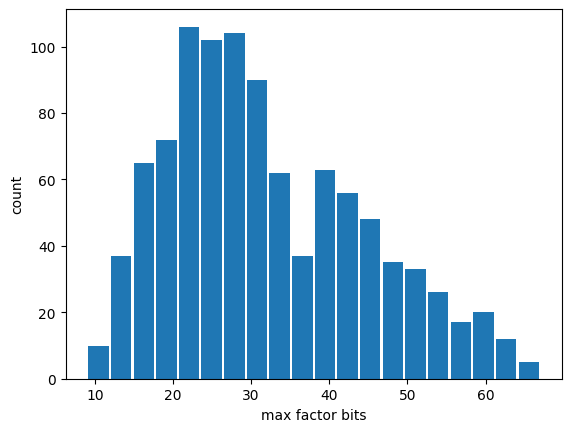

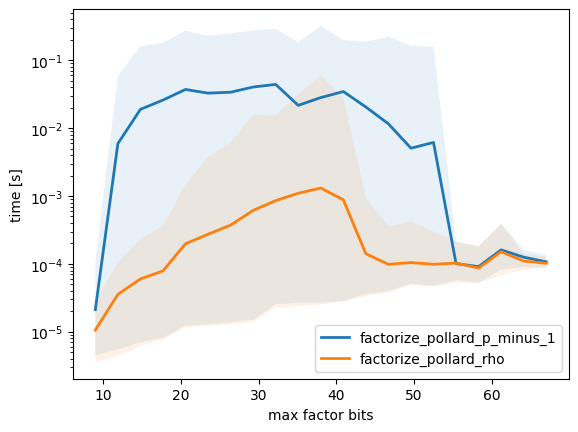

In [91]:
key = lambda r: max(r["factors_rho"]).bit_length()

values = [key(r) for r in results]
counts, bins = np.histogram(values, bins=20)
plt.hist(bins[:-1], bins, weights=counts, rwidth=0.9)
plt.xlabel("max factor bits")
plt.ylabel("count")
plt.show()

data_bins = group_by(results, key, bins)

nonempty = [data for data in data_bins if data]
mask = np.array([len(data) > 0 for data in data_bins])
bins = bins[mask]

# Re-evaluate times for the new bins
times_p1 = np.array([np.mean([r["time_p1"] for r in data]) for data in nonempty])
times_min_p1 = np.array([np.min([r["time_p1"] for r in data]) for data in nonempty])
times_max_p1 = np.array([np.max([r["time_p1"] for r in data]) for data in nonempty])

times_rho = np.array([np.mean([r["time_rho"] for r in data]) for data in nonempty])
times_min_rho = np.array([np.min([r["time_rho"] for r in data]) for data in nonempty])
times_max_rho = np.array([np.max([r["time_rho"] for r in data]) for data in nonempty])

fig, ax = plt.subplots()
ax.semilogy(bins, times_p1, linewidth=2, label="factorize_pollard_p_minus_1")
ax.fill_between(bins, times_min_p1, times_max_p1, alpha=0.1)
ax.semilogy(bins, times_rho, linewidth=2, label="factorize_pollard_rho")
ax.fill_between(bins, times_min_rho, times_max_rho, alpha=0.1)
ax.set_xlabel("max factor bits")
ax.set_ylabel("time [s]")
ax.legend()
plt.show()

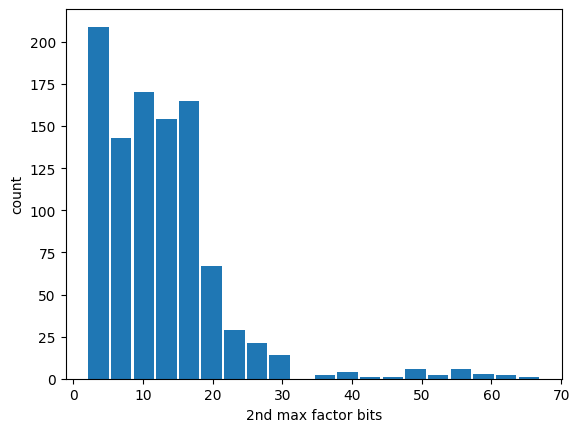

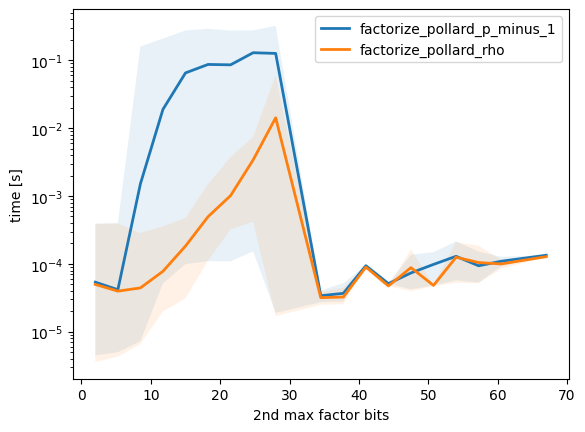

In [92]:
def key_2nd_max(r):
    sorted_factors = sorted(r["factors_rho"])
    if len(sorted_factors) >= 2:
        return sorted_factors[-2].bit_length()
    return sorted_factors[-1].bit_length()

values = [key_2nd_max(r) for r in results]
counts, bins = np.histogram(values, bins=20)
plt.hist(bins[:-1], bins, weights=counts, rwidth=0.9)
plt.xlabel("2nd max factor bits")
plt.ylabel("count")
plt.show()

data_bins = group_by(results, key_2nd_max, bins)

nonempty = [data for data in data_bins if data]
mask = np.array([len(data) > 0 for data in data_bins])
bins = bins[mask]

times_p1 = np.array([np.mean([r["time_p1"] for r in data]) for data in nonempty])
times_min_p1 = np.array([np.min([r["time_p1"] for r in data]) for data in nonempty])
times_max_p1 = np.array([np.max([r["time_p1"] for r in data]) for data in nonempty])

times_rho = np.array([np.mean([r["time_rho"] for r in data]) for data in nonempty])
times_min_rho = np.array([np.min([r["time_rho"] for r in data]) for data in nonempty])
times_max_rho = np.array([np.max([r["time_rho"] for r in data]) for data in nonempty])

fig, ax = plt.subplots()
ax.semilogy(bins, times_p1, linewidth=2, label="factorize_pollard_p_minus_1")
ax.fill_between(bins, times_min_p1, times_max_p1, alpha=0.1)
ax.semilogy(bins, times_rho, linewidth=2, label="factorize_pollard_rho")
ax.fill_between(bins, times_min_rho, times_max_rho, alpha=0.1)
ax.set_xlabel("2nd max factor bits")
ax.set_ylabel("time [s]")
ax.legend()
plt.show()

100%|██████████| 50/50 [00:12<00:00,  3.99it/s]


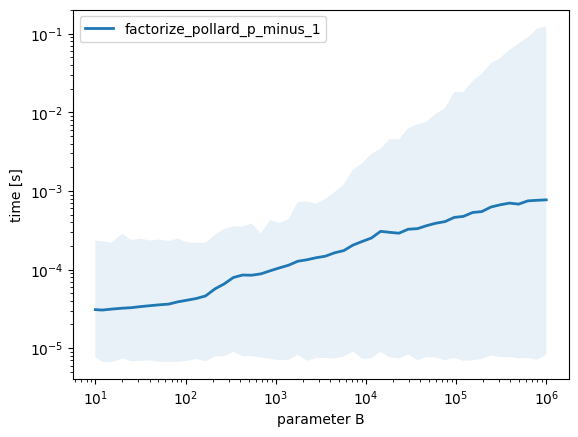

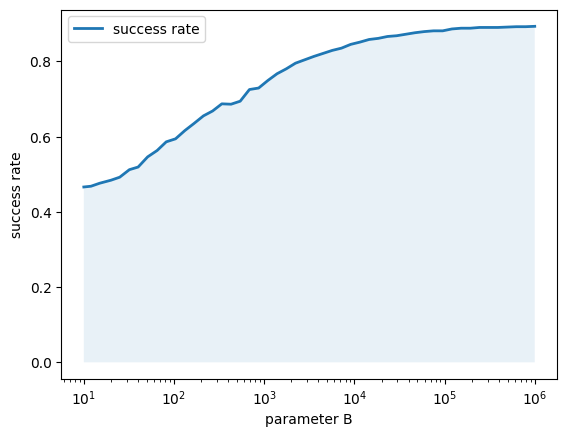

In [93]:
b_values = np.logspace(1, 6, 50).astype(int)

test_numbers = [rand_int(random.randint(40, 60)) for _ in range(1000)]

times_mean = []
times_min = []
times_max = []
success_rates = []

for B_val in tqdm(b_values):
    successes = 0
    times = []

    for n in test_numbers:
        with stopwatch(silent=True) as s:
            res = factorize_pollard_p_minus_1(n, B=int(B_val), max_retries=1)

        times.append(s.elapsed)
        if res is not None:
            successes += 1

    times_mean.append(np.mean(times))
    times_min.append(np.min(times))
    times_max.append(np.max(times))
    success_rates.append(successes / len(test_numbers))

times_mean = np.array(times_mean)
times_min = np.array(times_min)
times_max = np.array(times_max)
success_rates = np.array(success_rates)

fig, ax = plt.subplots()
ax.loglog(b_values, times_mean, linewidth=2, label="factorize_pollard_p_minus_1")
ax.fill_between(b_values, times_min, times_max, alpha=0.1)
ax.set_xlabel("parameter B")
ax.set_ylabel("time [s]")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.semilogx(b_values, success_rates, linewidth=2, label="success rate")
ax.fill_between(b_values, 0, success_rates, alpha=0.1)
ax.set_xlabel("parameter B")
ax.set_ylabel("success rate")
ax.legend()
plt.show()

In [94]:
magic_n = 393153263702980669137355399246611499921

with stopwatch() as s:
    res_rho = factorize_pollard_rho(magic_n)
print("Rho factors:", res_rho)

with stopwatch() as s:
    res_p1 = factorize_pollard_p_minus_1(magic_n)
print("p-1 factors:", res_p1)

elapsed: 0.000 s
Rho factors: Counter({393153263702980669137355399246611499921: 1})
elapsed: 0.000 s
p-1 factors: Counter({393153263702980669137355399246611499921: 1})


## Metoda Fermata

Jeśli potrafimy wyrazić $n$ jako różnicę kwadratów: $n = x^2 - y^2$, to $x \pm y$ są dzielnikami $n$, jako że
$$
n = x^2 - y^2 = (x + y)(x - y)
$$
Metoda Fermata polega na poszukiwaniu $x$, $y$ o tej własności.
Zaczynamy z $x = \lceil \sqrt{n} \rceil$.
W kolejnych iteracjach zwiększamy $x$ co $1$ i sprawdzamy, czy $y^2 = x^2 - n$ jest pełnym kwadratem (czy $y$ jest liczbą całkowitą).

W implementacji może przydać się funkcja **[math.isqrt](https://docs.python.org/3/library/math.html#math.isqrt)**.

### Zadanie 5

1. Zaimplementuj metodę Fermata
2. Przetestuj zyski na liczbach $\leq 10^6$. Jak wypada porównanie z pozostałymi metodami? Czy metoda Fermata jest użyteczna jako metoda faktoryzacji ogólnego przeznaczenia?

### Rozwiązanie